# Modelo de Ising — Algoritmo de Metropolis-Hastings

Implementação da classe `IsingModel` com condições de fronteira periódicas,  
`J = 1`, `h = 0`, `kb = 1`, rede 2D quadrada de lado `L`, spins iniciais `+1`.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import CubicSpline, RegularGridInterpolator

J  = 1    # constante de acoplamento
h  = 0    # CORRIGIDO: era h=0.1 — o enunciado especifica h=0
kb = 1    # constante de Boltzmann
rnd = np.random.default_rng(seed=1)  # gerador de números aleatórios


# ── Classe do Modelo de Ising ────────────────────────────────────────────────
class IsingModel:

    def __init__(self, L, T):
        # parâmetros do modelo
        self.L = L
        self.T = T

        # rede com todos os spins = +1
        self.spins = np.ones((L, L))

        # listas para guardar a evolução das variáveis
        self.energies       = []
        self.magnetizations = []

    # ── energia de um spin individual (conta apenas vizinhos à direita e abaixo
    #    para evitar dupla contagem quando somado sobre todos os spins) ─────────
    def calc_ener_spin(self, i, j) -> float:
        L    = self.L
        own  = self.spins[i, j]
        # CORRIGIDO: substituído método neighbours (usava np.isin de forma errada)
        #            por acesso directo com índices periódicos via %
        right = self.spins[i,         (j + 1) % L]
        down  = self.spins[(i + 1) % L,  j       ]
        energy = -J * own * (right + down) - h * own
        return energy

    # ── energia total do sistema ─────────────────────────────────────────────
    def calc_ener(self) -> float:
        # CORRIGIDO: substituído duplo loop Python por operações numpy vectorizadas
        #            (ordens de grandeza mais rápido para L grandes)
        right  = np.roll(self.spins, -1, axis=1)   # vizinhos à direita
        down   = np.roll(self.spins, -1, axis=0)   # vizinhos de baixo
        energy = -J * np.sum(self.spins * (right + down)) - h * np.sum(self.spins)
        return energy

    # ── magnetização por spin m = M/L² ───────────────────────────────────────
    def calc_mag(self) -> float:
        M   = J * np.sum(self.spins)
        mag = M / self.L**2
        return mag

    # ── inverte o spin (i,j) ─────────────────────────────────────────────────
    def flip(self, i, j) -> None:
        self.spins[i, j] *= -1

    # ── iteração de Monte Carlo (Metropolis-Hastings) ─────────────────────────
    def iter_monte_carlo(self, n_iter):
        L = self.L

        # CORRIGIDO: arrays numpy pré-alocados em vez de listas com append
        #            (evita realocação de memória repetida → mais eficiente)
        self.energies       = np.empty(n_iter + 1)
        self.magnetizations = np.empty(n_iter + 1)

        # estado inicial
        E   = self.calc_ener()
        mag = self.calc_mag()
        self.energies[0]       = E
        self.magnetizations[0] = mag

        # CORRIGIDO (optimização): pré-gerar todos os números aleatórios fora
        #           do loop reduz o overhead de chamadas repetidas ao gerador
        i_vals = rnd.integers(0, L,        size=n_iter)
        j_vals = rnd.integers(0, L,        size=n_iter)
        u_vals = rnd.uniform (0.0, 1.0,    size=n_iter)

        for k in tqdm(range(n_iter), desc=f"L={L:6d}, T={self.T:8.4f}"):
            i   = i_vals[k]
            j   = j_vals[k]
            u   = u_vals[k]
            own = self.spins[i, j]   # spin antes do flip

            # CORRIGIDO: substituído método neighbours (usava np.isin de forma errada)
            #            Acesso directo aos 4 vizinhos com índices periódicos via %
            sumviz = (self.spins[i,        (j + 1) % L] +
                      self.spins[i,        (j - 1) % L] +
                      self.spins[(i + 1) % L,  j       ] +
                      self.spins[(i - 1) % L,  j       ])

            delta = 2.0 * own * (J * sumviz + h)   # ΔE ao flippar o spin

            if delta < 0 or np.exp(-delta / (kb * self.T)) > u:
                # flip aceite: actualizar spin, energia e magnetização
                self.flip(i, j)
                E   += delta
                # CORRIGIDO: magnetização actualizada incrementalmente
                #            (era calc_mag() a cada passo → custo O(L²) por iteração)
                #            quando own flipa para -own: ΔM = J*(-2*own) → Δmag = -2*J*own/L²
                mag -= 2.0 * J * own / L**2

            self.energies[k + 1]       = E
            self.magnetizations[k + 1] = mag

    @property
    def energy(self):
        # aceder ao array com as energias
        return np.array(self.energies)

    @property
    def magnetization(self):
        # aceder ao array com as magnetizações
        return np.array(self.magnetizations)

---
## Exercício 1 — Tempo de Termalização

### 1(a)

Para cada combinação de $L \in \{16, 32, 64, 128\}$ e $T \in \{1, 2, 3, 4\}$,
corre a simulação e representa a energia média por spin

$$e \equiv \frac{E}{L^2}$$

em função do número de iteração $N$.

O número de iterações é escalado com $L^2$ (número de spins) para que o número
de *varrimentos* (sweeps $= N/L^2$) seja idêntico para todos os tamanhos.

L=   128, T=  4.0000: 100%|██████████| 163840/163840 [00:00<00:00, 928661.66it/s]


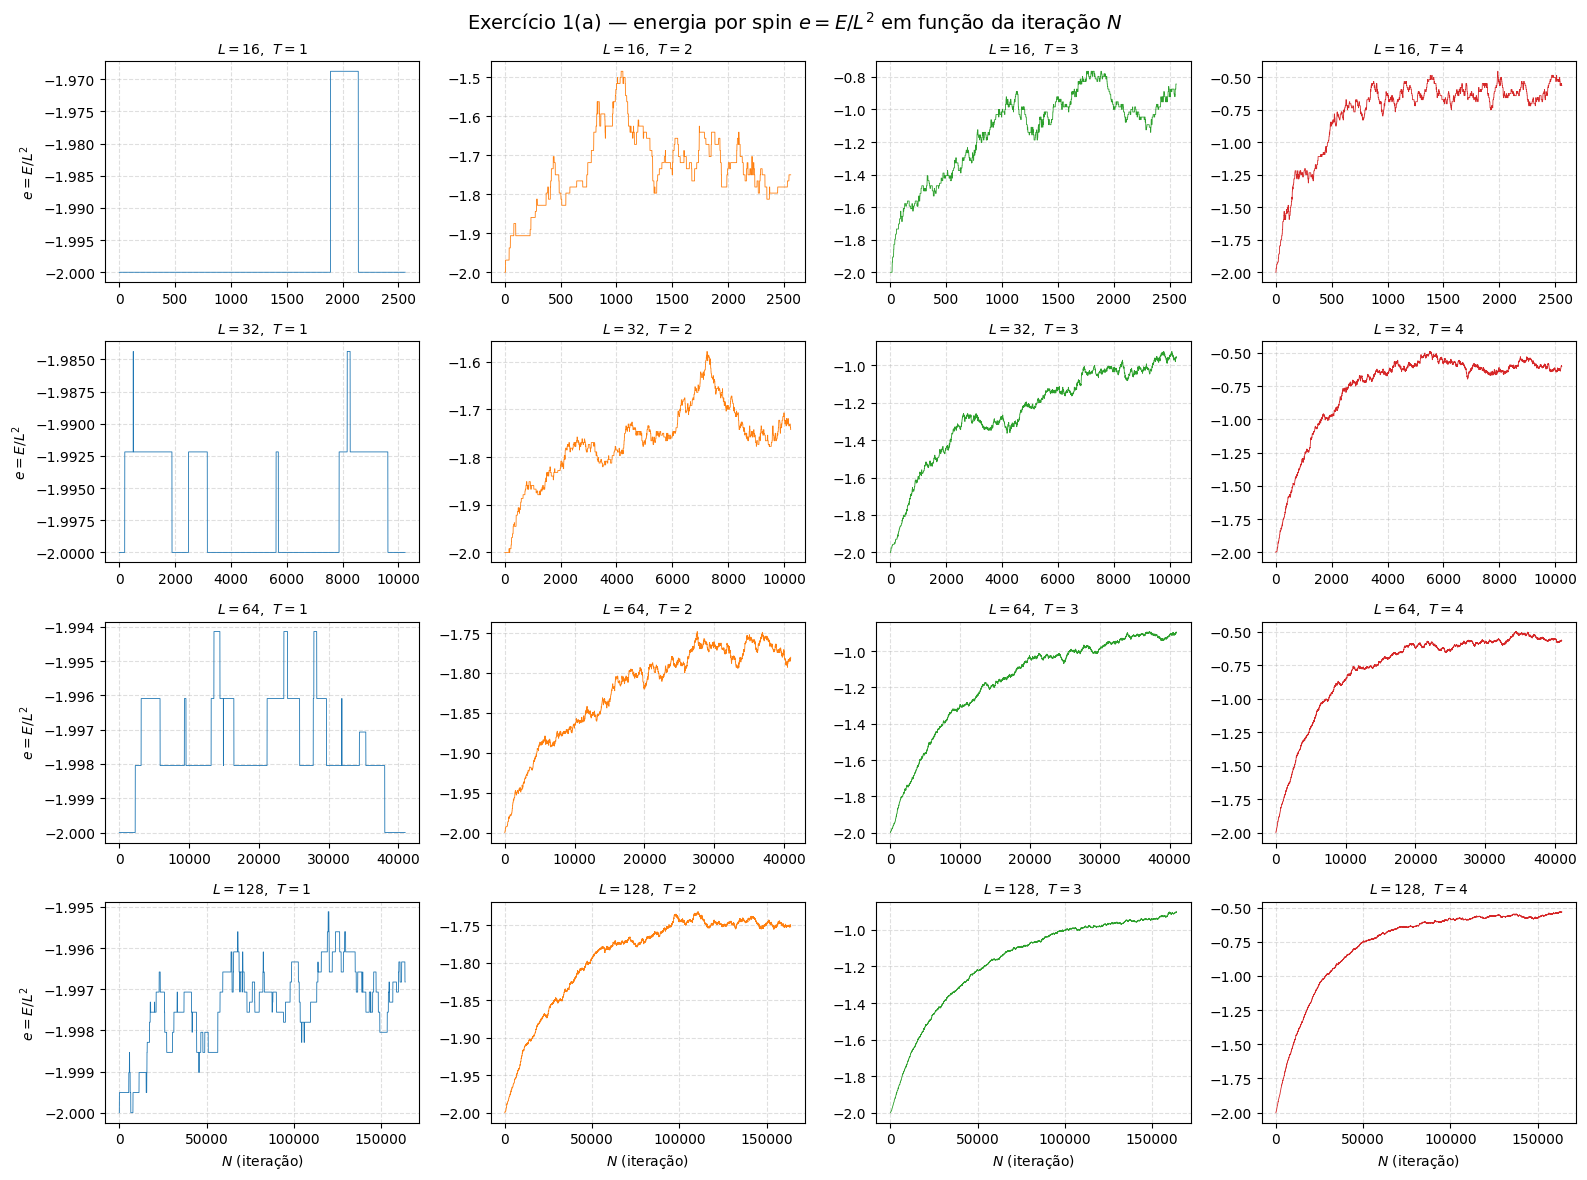

In [13]:
# ── Parâmetros do exercício 1(a) ─────────────────────────────────────────────
L_values = [16, 32, 64, 128]
T_values = [1, 2, 3, 4]
n_sweeps = 10    # número de varrimentos (sweeps) por simulação
                 # n_iter = n_sweeps * L² para cada L
                 # 10 sweeps é suficiente para ver o transiente;
                 # não precisamos de esperar pela termalização completa —
                 # é exactamente τterm que estamos a tentar medir

# ── Simulações ───────────────────────────────────────────────────────────────
# Guardar e = E/L² para cada (L, T)
results = {}

for L in L_values:
    n_iter = n_sweeps * L**2   # nº de iterações escalonado com L²
    for T in T_values:
        model = IsingModel(L, T)
        model.iter_monte_carlo(n_iter)
        results[(L, T)] = model.energy / L**2   # e = E/L²

# ── Gráficos — grelha 4×4: linhas = L, colunas = T ──────────────────────────
fig, axes = plt.subplots(
    len(L_values), len(T_values),
    figsize=(16, 12),
    sharex=False, sharey=False
)
fig.suptitle(
    r"Exercício 1(a) — energia por spin $e = E/L^2$ em função da iteração $N$",
    fontsize=14
)

cores = ["C0", "C1", "C2", "C3"]   # uma cor por temperatura

for row, L in enumerate(L_values):
    for col, T in enumerate(T_values):
        ax = axes[row, col]
        e  = results[(L, T)]
        N  = np.arange(len(e))         # eixo x: número de iteração

        ax.plot(N, e, lw=0.6, color=cores[col])
        ax.set_title(f"$L = {L}$,  $T = {T}$", fontsize=10)
        ax.grid(True, ls="--", alpha=0.4)

        # rótulos apenas nas bordas exteriores
        if row == len(L_values) - 1:
            ax.set_xlabel("$N$ (iteração)")
        if col == 0:
            ax.set_ylabel(r"$e = E/L^2$")

plt.tight_layout()
plt.show()

### 1(b)

Fit da energia por spin à função de termalização:

$$e(N) = e_f + (e_0 - e_f)\,e^{-N/\tau_\mathrm{term}}$$

- $e_0 = -2$ — energia inicial (todos os spins `+1`, fixo)
- $e_f(L,T)$ — energia de equilíbrio
- $\tau_\mathrm{term}(L,T)$ — tempo de termalização

Usa-se `scipy.optimize.curve_fit`. Os dados são subamostrados a ~500 pontos
para reduzir ruído antes do fit.

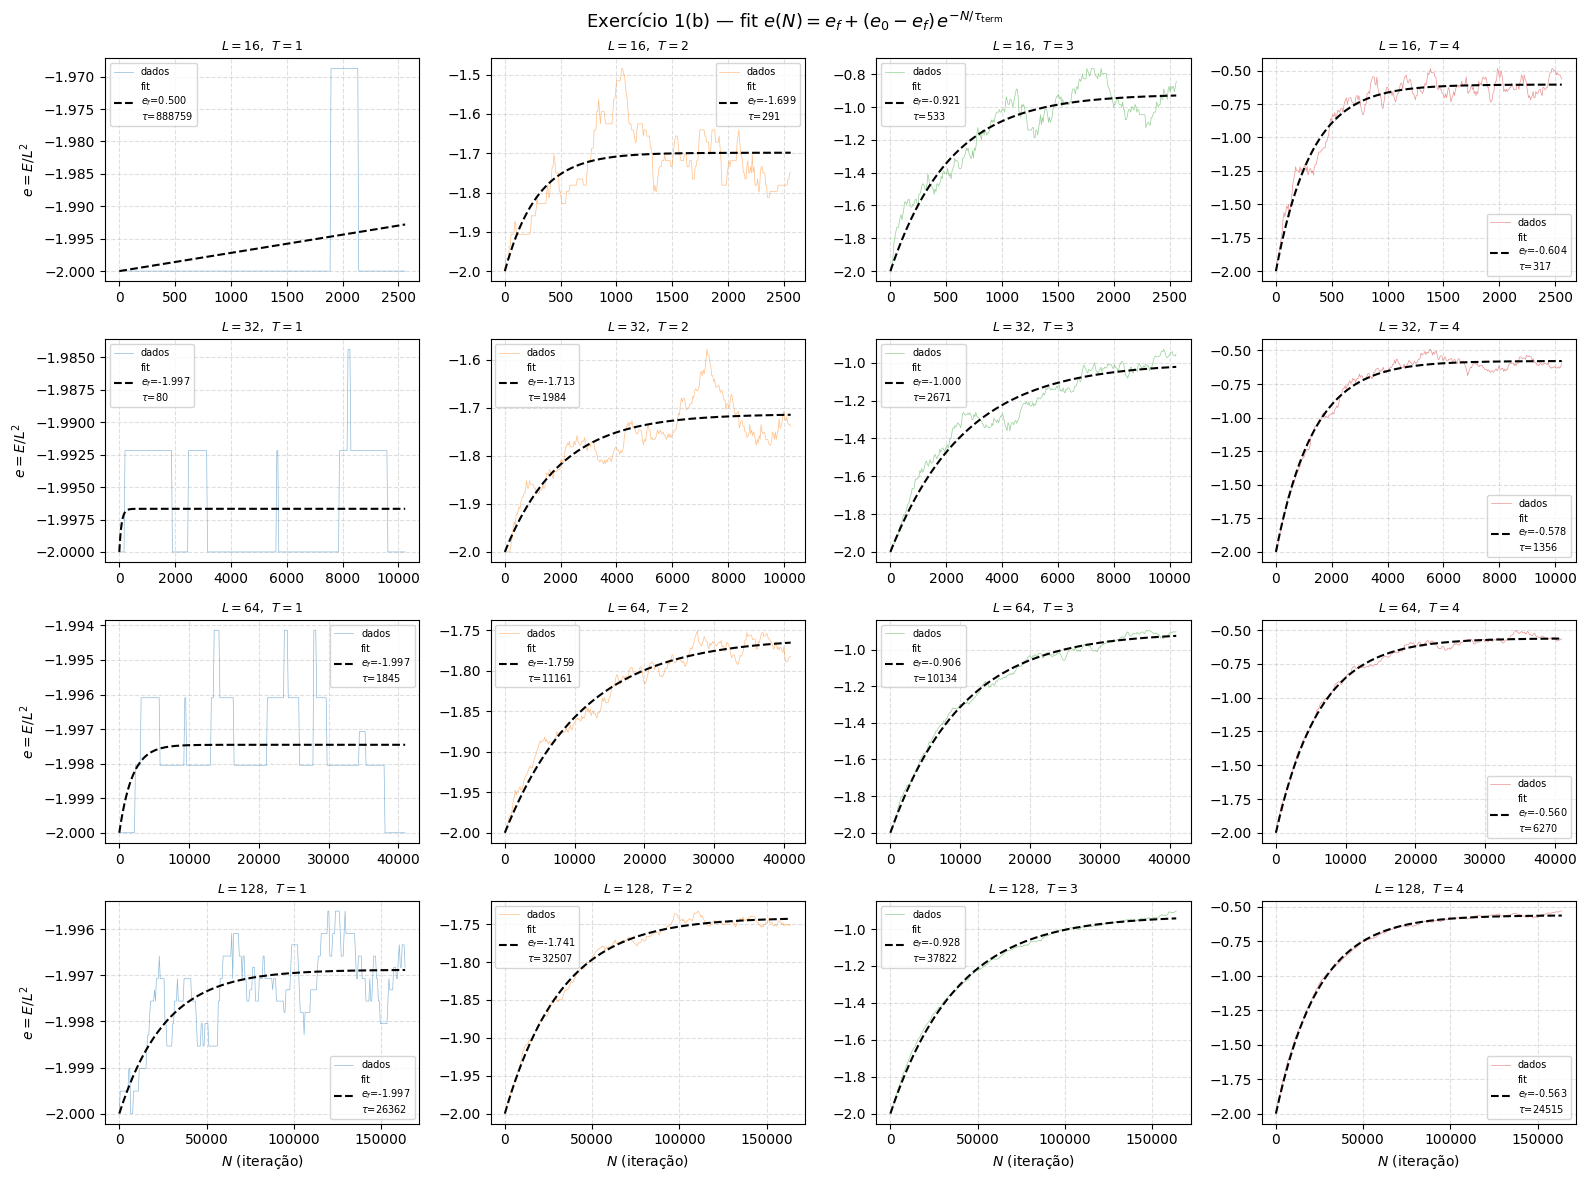


    L     T         ef      ±σ_ef        τ_term          ±σ_τ
──────────────────────────────────────────────────────────
   16     1     0.5000   840.5880      888758.9   299156084.8
   16     2    -1.6986     0.0041         291.4          21.4
   16     3    -0.9211     0.0077         532.8          13.9
   16     4    -0.6042     0.0042         316.8           4.9
   32     1    -1.9967     0.0002          80.4          98.2
   32     2    -1.7127     0.0031        1983.9          81.2
   32     3    -1.0004     0.0061        2671.4          51.1
   32     4    -0.5784     0.0026        1356.1          12.0
   64     1    -1.9975     0.0001        1845.1         423.3
   64     2    -1.7591     0.0012       11161.1         173.4
   64     3    -0.9061     0.0022       10133.6          65.5
   64     4    -0.5597     0.0016        6269.8          31.9
  128     1    -1.9969     0.0000       26361.7        1716.3
  128     2    -1.7412     0.0005       32506.8         236.4
  128     

In [14]:
# ── Exercício 1(b) ───────────────────────────────────────────────────────────

# Função de termalização — e0 = -2 fixo (todos os spins começam a +1)
def therm_model(N, ef, tau):
    e0 = -2.0
    return ef + (e0 - ef) * np.exp(-N / tau)

fit_params = {}   # (L, T) -> array([ef, tau])
fit_errors  = {}  # (L, T) -> array([sigma_ef, sigma_tau])

for L in L_values:
    for T in T_values:
        
        e = results[(L, T)]
        N = np.arange(len(e), dtype=float)

        # Subamostrar para ~500 pontos: reduz ruído MC e custo do fit
        step  = max(1, len(e) // 500)
        e_sub = e[::step]
        N_sub = N[::step]

        # Estimativas iniciais
        n_tail = max(1, len(e_sub) // 10)
        ef_p0  = float(e_sub[-n_tail:].mean())  # média do último 10% → estimativa de ef
        tau_p0 = float(L**2)                    # ordem de grandeza típica de tau

        try:
            popt, pcov = curve_fit(
                therm_model, N_sub, e_sub,
                p0    = [ef_p0, tau_p0],
                # ef ∈ [-2.5, 0.5]  (ordenado→desordenado, com margem numérica)
                # tau ∈ [1, +∞)     (deve ser positivo)
                bounds = ([-2.5, 1.0], [0.5, np.inf]),
                maxfev = 10000
            )
            perr = np.sqrt(np.diag(pcov))
        except (RuntimeError, ValueError):
            # fit não convergiu (pode acontecer a T=1 onde a curva é quase plana)
            popt = np.full(2, np.nan)
            perr = np.full(2, np.nan)

        fit_params[(L, T)] = popt
        fit_errors [(L, T)] = perr

# ── Gráficos: dados + fit ────────────────────────────────────────────────────
fig, axes = plt.subplots(len(L_values), len(T_values), figsize=(16, 12))
fig.suptitle(
    r"Exercício 1(b) — fit $e(N)=e_f+(e_0-e_f)\,e^{-N/\tau_\mathrm{term}}$",
    fontsize=13
)

for row, L in enumerate(L_values):
    for col, T in enumerate(T_values):

        ax = axes[row, col]
        e  = results[(L, T)]
        N  = np.arange(len(e))

        # dados subamostrados para visualização
        step = max(1, len(e) // 300)
        ax.plot(N[::step], e[::step], lw=0.5, color=f"C{col}", alpha=0.5, label="dados")

        # curva de fit
        ef, tau = fit_params[(L, T)]
        if not np.isnan(ef):
            N_fit = np.linspace(0, N[-1], 500)
            ax.plot(
                N_fit, therm_model(N_fit, ef, tau),
                color="k", lw=1.5, ls="--",
                label=f"fit\n$e_f$={ef:.3f}\n$\\tau$={tau:.0f}"
            )

        ax.set_title(f"$L={L}$,  $T={T}$", fontsize=9)
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, ls="--", alpha=0.4)
        if row == len(L_values) - 1:
            ax.set_xlabel("$N$ (iteração)")
        if col == 0:
            ax.set_ylabel(r"$e = E/L^2$")

plt.tight_layout()
plt.show()

# ── Tabela de resultados ─────────────────────────────────────────────────────
print(f"\n{'L':>5}  {'T':>4}  {'ef':>9}  {'±σ_ef':>9}  {'τ_term':>12}  {'±σ_τ':>12}")
print("─" * 58)
for L in L_values:
    for T in T_values:
        ef,  tau  = fit_params[(L, T)]
        sef, stau = fit_errors [(L, T)]
        print(f"{L:>5}  {T:>4}  {ef:>9.4f}  {sef:>9.4f}  {tau:>12.1f}  {stau:>12.1f}")


### 1(c)

Representação gráfica do tempo de termalização: $\tau_{term}(L,T)$

Utilizou-se a função "RegularGridInterpolator" do módulo scipy.interpolate.
Para os pontos da interpolação usaram-se os recolhidos na etapa anterior.

In [ ]:
L_vals = np.array(L_values)
T_vals = np.array(T_values)

# τ e erro a partir do fit_params
tau = np.array([
    [fit_params[(L, T)][1] for T in T_vals]
    for L in L_vals
])

err = np.array([
    [fit_errors[(L, T)][1] for T in T_vals]
    for L in L_vals
])

assert tau.shape == err.shape == (len(L_vals), len(T_vals))

interp_tau = RegularGridInterpolator((L_vals, T_vals), tau, method="cubic")
interp_err = RegularGridInterpolator((L_vals, T_vals), err, method="cubic")

def plot_region(L_min=None, L_max=None, T_min=None, T_max=None, dim=200):
    """
    Plota tau(L,T) com informação de erro.
    Se não definir limites → usa todo o espaço.
    """

    # limites automáticos
    L_min = L_vals.min() if L_min is None else L_min
    L_max = L_vals.max() if L_max is None else L_max
    T_min = T_vals.min() if T_min is None else T_min
    T_max = T_vals.max() if T_max is None else T_max

    # grelha fina
    L_f = np.linspace(L_min, L_max, dim)
    T_f = np.linspace(T_min, T_max, dim)

    Lg, Tg = np.meshgrid(L_f, T_f, indexing="ij")

    pts = np.column_stack([Lg.ravel(), Tg.ravel()])

    # interpolação
    tau_f = interp_tau(pts).reshape(Lg.shape)
    err_f = interp_err(pts).reshape(Lg.shape)

    # normalizar erro para visualização
    err_norm = err_f / (np.nanmax(err_f) + 1e-12)

    # colormap baseado em confiança (baixo erro → mais forte)
    colors = plt.cm.viridis(1 - err_norm)
    colors[..., -1] = 1.0  # alpha fixo

    # plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        Lg, Tg, tau_f,
        facecolors=colors,
        shade=False
    )

    ax.set_xlabel("L")
    ax.set_ylabel("T")
    ax.set_zlabel("tau_term")

    plt.show()

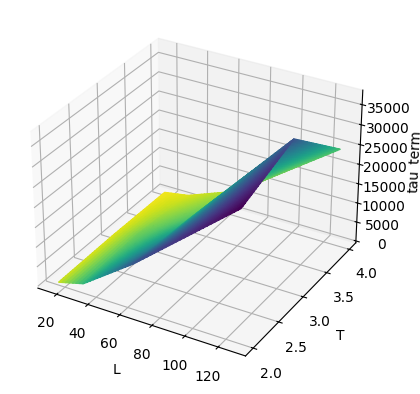

In [22]:
plot_region(16, 128, 2, 4)
# Temos de usar limites válidos, têm de ser pontos do dataset recolhido

L=   128, T=  3.9000: 100%|██████████| 1000000/1000000 [00:01<00:00, 907352.88it/s]


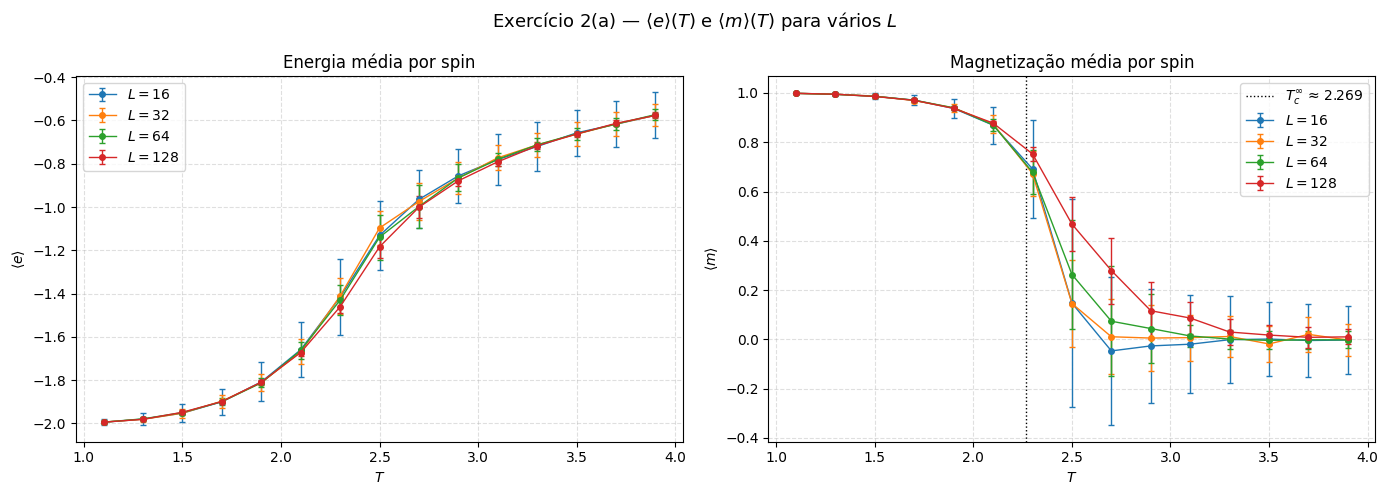

In [23]:
tau_mat = np.zeros((len(L_vals), len(T_vals)))

for iL, L in enumerate(L_vals):
    for iT, T in enumerate(T_vals):
        model = IsingModel(L, T)
        model.iter_monte_carlo(n_sweeps * L**2)
        e = model.energy / L**2
        N = np.arange(len(e), dtype=float)
        step  = max(1, len(e) // 500)
        e_sub, N_sub = e[::step], N[::step]
        n_tail = max(1, len(e_sub) // 10)
        try:
            popt, _ = curve_fit(
                therm_model, N_sub, e_sub,
                p0     = [float(e_sub[-n_tail:].mean()), float(L**2)],
                bounds = ([-2.5, 1.0], [0.5, np.inf]),
                maxfev = 10000,
            )
            tau_mat[iL, iT] = popt[1]
        except (RuntimeError, ValueError):
            tau_mat[iL, iT] = np.nan

interp_tau = RegularGridInterpolator((L_vals, T_vals), tau_mat, method='cubic', bounds_error=True, fill_value=None)

L_values_2a = [16, 32, 64, 128]
T_values_2a = np.array([1.1+a*0.2 for a in range(15)])
n_meas      = 1_000_000

e_mean = np.zeros((len(L_values_2a), len(T_values_2a)))
e_std  = np.zeros_like(e_mean)
m_mean = np.zeros_like(e_mean)
m_std  = np.zeros_like(e_mean)

for iL, L in enumerate(L_values_2a):
    for iT, T in enumerate(T_values_2a):
        tau_estimado = float(interp_tau([[L, T]])[0])

        # Se a estimativa for NaN (porque a curve_fit falhou antes), usamos um valor por defeito.
        # Exemplo: assumir tau = 100 como fallback.
        if np.isnan(tau_estimado):
            tau_estimado = 100.0  

        n_term = max(1, int(4 * tau_estimado))

        model = IsingModel(L, T)
        model.iter_monte_carlo(n_term)        # termalização
        model.iter_monte_carlo(n_meas)        # medição

        e_arr = model.energy / L**2
        m_arr = model.magnetization

        e_mean[iL, iT] = e_arr.mean()
        e_std [iL, iT] = e_arr.std()
        m_mean[iL, iT] = m_arr.mean()
        m_std [iL, iT] = m_arr.std()

# ── Gráficos ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    r"Exercício 2(a) — $\langle e \rangle(T)$ e $\langle m \rangle(T)$ para vários $L$",
    fontsize=13
)
cores = ["C0", "C1", "C2", "C3"]

for iL, L in enumerate(L_values_2a):
    axes[0].errorbar(T_values_2a, e_mean[iL], yerr=e_std[iL],
                     marker="o", ms=4, lw=1, capsize=2,
                     color=cores[iL], label=f"$L = {L}$")
    axes[1].errorbar(T_values_2a, m_mean[iL], yerr=m_std[iL],
                     marker="o", ms=4, lw=1, capsize=2,
                     color=cores[iL], label=f"$L = {L}$")

Tc_inf = 2.0 / np.log(1.0 + np.sqrt(2.0))
axes[1].axvline(Tc_inf, color="k", ls=":", lw=1, label=f"$T_c^\\infty$ ≈ {Tc_inf:.3f}")

axes[0].set(xlabel="$T$", ylabel=r"$\langle e \rangle$", title="Energia média por spin")
axes[1].set(xlabel="$T$", ylabel=r"$\langle m \rangle$", title="Magnetização média por spin")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.4); ax.legend()

plt.tight_layout(); plt.show()

2. b)
Determinação da derivada parcial e respetiva representação gráfica:
$$ c = \frac{\partial e}{\partial T} $$
Com propagação de erro para $\frac{\partial e}{\partial T}(T^i)$ dado pela seguinte equação:
$$\sigma_{de/dt}^{i} = \frac{\sqrt{(\sigma_{i+1\,\text{e}})^2 + (\sigma_{i-1\,\text{e}})^2}}{2h}$$

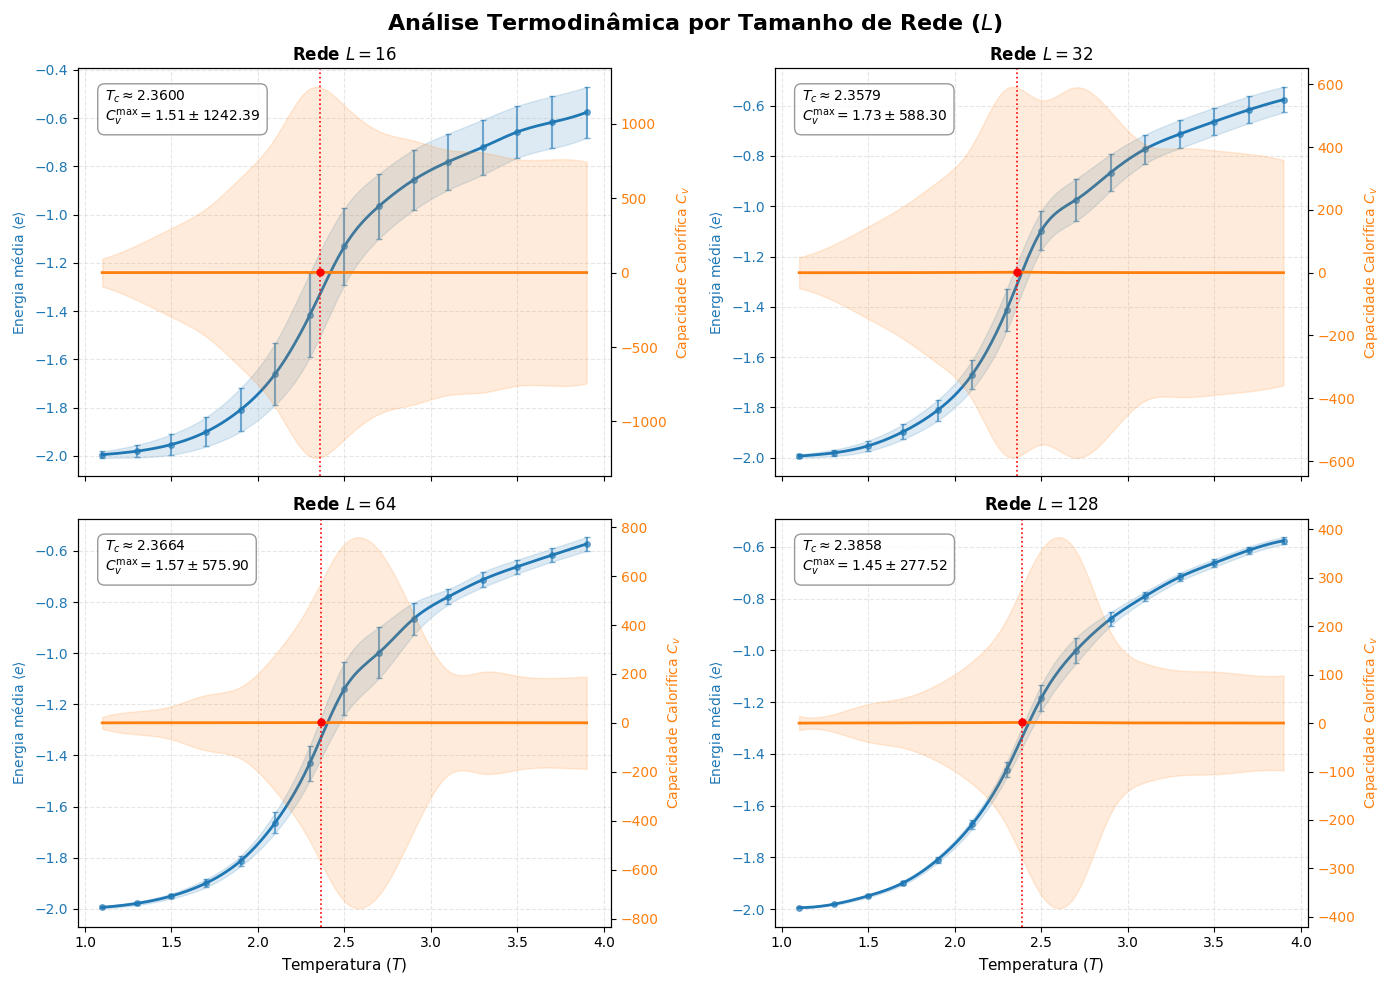

In [24]:
E_func = RegularGridInterpolator((L_values_2a, T_values_2a), e_mean, method="cubic", bounds_error=False, fill_value=None)
E_std_func = RegularGridInterpolator((L_values_2a, T_values_2a), e_std, method="cubic", bounds_error=False, fill_value=None)
#os nossos pontos

size = 128
h = 1e-4

def energy_temp(temp, L=size):   
    temp = np.atleast_1d(temp) # Garante que funciona tanto para um número como para um array
    # Cria uma coluna cheia de 'L' e junta-a com a coluna de temperaturas
    pontos = np.column_stack((np.full_like(temp, L), temp))
    return E_func(pontos)

def energy_std_temp(temp, L=size):
    # Função do erro associado à energia.
    temp = np.atleast_1d(temp) 
    pontos = np.column_stack((np.full_like(temp, L), temp))
    return E_std_func(pontos)

def heat_cap_std(temp):
    # Função do erro da derivada - da capacidade calorífica
    prec = h
    return np.sqrt(energy_std_temp(temp+prec)**2+energy_std_temp(temp-prec)**2)/(2*prec)

def derivada(f):
    def der(x):
        prec = h
        val = (f(x+prec)-f(x-prec)) / (2 * prec)
        return val
    return der

def biss(a, b, f):
    # método para encontrar o zero da segunda derivada - Temperatura crítica - ponto de inflexão do gráfico da energia
    epsilon = h
    x_ = (a+b)/2
    thres = 0

    if f(a)*f(b) > 0:
        raise Exception("No root inside.")

    while np.abs(f(x_)) > epsilon:
        
        x_ = (a+b)/2

        if f(x_)*f(a)<=0:
            b = x_
        else:
            a = x_
        thres += 1
        if thres == 100000:
            break

    return x_


# ── Preparação do Eixo X Suave para os Gráficos ──────────────────────────────
X_smooth = np.linspace(1.1, 3.9, 200)

# ── Configuração da Matriz 2x2 de Gráficos ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle("Análise Termodinâmica por Tamanho de Rede ($L$)", fontsize=16, fontweight='bold')

# Mapeamento com os 4 valores de L para distribuir na matriz
config_L = [
    {"L": 16,  "row": 0, "col": 0},
    {"L": 32,  "row": 0, "col": 1},
    {"L": 64,  "row": 1, "col": 0},
    {"L": 128, "row": 1, "col": 1}
]

for config in config_L:
    L_atual = config["L"]
    row = config["row"]
    col = config["col"]
    
    # Selecionar o quadrante da matriz
    ax_en = axes[row, col]        # Eixo Y Esquerdo (Energia)
    ax_cv = ax_en.twinx()         # Eixo Y Direito (Capacidade Calorífica)
    
    # Índice correspondente aos teus dados brutos originais do Monte Carlo
    iL = L_values_2a.index(L_atual)
    
    # ── 1. Adaptar as tuas funções dinamicamente para o L_atual ──────────────
    # Criamos versões locais das tuas funções que usam explicitamente o L_atual
    energy_local = lambda t: energy_temp(t, L=L_atual)
    energy_std_local = lambda t: energy_std_temp(t, L=L_atual)
    
    # A tua fórmula exata de propagação de erro adaptada para o L_atual
    heat_cap_std_local = lambda t: np.sqrt(energy_std_local(t+h)**2 + energy_std_local(t-h)**2) / (2*h)
    
    # Usando a tua função 'derivada' nas funções locais
    heat_cap_local = derivada(energy_local)
    dc_local = derivada(heat_cap_local)
    
    # ── 2. Avaliar as curvas completas para o gráfico suave ──────────────────
    y_energy = energy_local(X_smooth)
    err_energy = energy_std_local(X_smooth)
    
    y_cv = heat_cap_local(X_smooth)
    err_cv = heat_cap_std_local(X_smooth)
    
    # ── 3. Encontrar o Pico (Tc) e o seu Erro usando a tua Bisseção ──────────
    try:
        # Encontra a raiz da derivada de Cv (onde se anula o declive)
        c_atual = biss(2.0, 2.5, dc_local)
        
        # Avaliar o valor de Cv e o respetivo erro exatamente no ponto c_atual
        cv_no_pico = heat_cap_local(c_atual)[0]
        erro_cv_pico = heat_cap_std_local(c_atual)[0]
    except Exception:
        # Salvaguarda caso a bisseção falhe para redes muito pequenas fora do intervalo [2, 2.5]
        c_atual = None
    
    # ── 4. Desenhar os Plots (Energia - Eixo Esquerdo) ───────────────────────
    ax_en.errorbar(T_values_2a, e_mean[iL], yerr=e_std[iL], fmt='o', color='C0', 
                   capsize=2, ms=4, alpha=0.6, label="Dados MC")
    ax_en.plot(X_smooth, y_energy, color='C0', lw=2, label=r"$\langle e \rangle$ Cúbico")
    ax_en.fill_between(X_smooth, y_energy - err_energy, y_energy + err_energy, 
                       color='C0', alpha=0.15)
    
    ax_en.set_ylabel(r"Energia média $\langle e \rangle$", color='C0')
    ax_en.tick_params(axis='y', labelcolor='C0')
    ax_en.grid(True, ls="--", alpha=0.3)
    
    # ── 5. Desenhar os Plots (Capacidade Calorífica - Eixo Direito) ──────────
    ax_cv.plot(X_smooth, y_cv, color='C1', lw=2, label=r"$C_v$ (Derivada)")
    ax_cv.fill_between(X_smooth, y_cv - err_cv, y_cv + err_cv, 
                       color='C1', alpha=0.15)
    
    ax_cv.set_ylabel(r"Capacidade Calorífica $C_v$", color='C1')
    ax_cv.tick_params(axis='y', labelcolor='C1')
    
    # ── 6. Adicionar os Valores e Erros calculados na Caixa de Texto ─────────
    if c_atual is not None:
        # Desenha a linha vertical pontilhada e o marcador no topo do pico
        ax_cv.axvline(c_atual, color="red", ls=":", lw=1.2)
        ax_cv.plot(c_atual, cv_no_pico, 'ro', ms=5)
        
        # String formatada com os valores e erros específicos deste L
        texto_resultados = (
            fr"$T_c \approx {c_atual:.4f}$" "\n"
            fr"$C_v^{{\max}} = {cv_no_pico:.2f} \pm {erro_cv_pico:.2f}$"
        )
        
        # Insere a caixa de texto informativa no quadrante
        ax_en.text(0.05, 0.95, texto_resultados, transform=ax_en.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    # Títulos e eixos
    ax_en.set_title(f"Rede $L = {L_atual}$", fontsize=12, fontweight='bold')
    if row == 1:
        ax_en.set_xlabel("Temperatura ($T$)", fontsize=11)

plt.tight_layout()
plt.show()

2c)

In [28]:
def metropolis_hastings_heat_cap(e_mean, size, temp):
    av_of_sq = 1
    sq_of_av = 1
    C = (av_of_sq - sq_of_av)/(size**2 * T**2)
    return C

print(e_mean)
print(L_vals)
print(T_vals)
print(e_mean[T_vals[0]][L_vals[0]])

[[-1.99470685 -1.98013327 -1.95261152 -1.89996121 -1.80821369 -1.65969989
  -1.41608079 -1.13161356 -0.96462484 -0.85608776 -0.78065714 -0.72020608
  -0.65712904 -0.61725931 -0.57578687]
 [-1.99399324 -1.98110106 -1.95289659 -1.89727756 -1.81175031 -1.66962182
  -1.41173091 -1.09677475 -0.97464404 -0.86626211 -0.77246513 -0.71289869
  -0.66310936 -0.61614694 -0.57589587]
 [-1.99442061 -1.97912512 -1.95009127 -1.89975822 -1.81278042 -1.66282243
  -1.43002952 -1.13938516 -0.99782208 -0.86538556 -0.77931563 -0.71234109
  -0.66137575 -0.61625442 -0.57277008]
 [-1.99434096 -1.98120911 -1.94864862 -1.8989707  -1.80937143 -1.67246541
  -1.46094779 -1.18390331 -1.00075411 -0.87872189 -0.79085458 -0.71694439
  -0.66259039 -0.61320076 -0.57667366]]
[ 16  32  64 128]
[1 2 3 4]


IndexError: index 16 is out of bounds for axis 0 with size 15